In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import scipy.sparse
import matplotlib.pyplot as plt

In [45]:
# Set the data to be loaded
# This raises a pytorch error but I think it's ok?
X = torch.load('X-mid-enc.pt')
y = torch.load('y-mid-enc.pt') 

/tmp/ipykernel_148398/2253259815.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  X = torch.load('X-mid-enc.pt')
/tmp/ipykernel_148398/2253259815.py:3: FutureWarning: You

In [46]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [33]:
import pickle

def load_dictionary_pickle(filename):
    """Loads a dictionary from a pickle file."""
    with open(filename, 'rb') as f:  # 'rb' for binary read
        return pickle.load(f)

# import dictionary and set vocab size
embedding_matrix = load_dictionary_pickle('mid-enc-em.pkl')
vocab_size, embedding_dim = list(embedding_matrix.size())

In [47]:
# Check
print('vocab size', vocab_size)
print('embedding dimension', embedding_dim)


vocab size 20001
embedding dimension 50


In [76]:
#Define Model (this is taken from Gemini--can it be improved?)
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers, output_size, embedding_matrix):
        super(LSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.embedding.weight.data.copy_(embedding_matrix) #load the pretrained embeddings.
        
        # Freeze embeddings. Tried both ways, "true" is unfreezed
        #self.embedding.weight.requires_grad = True 

        # Tried inserting dropout. Not sure
        self.lstm = nn.LSTM(embedding_dim, hidden_size, num_layers, dropout=0.3, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        embedded = self.embedding(x)
        out, _ = self.lstm(embedded)
        out = self.fc(out[:, -1, :])
        return out


In [77]:
# Use the GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)


cuda


In [78]:
# Set model parameters
hidden_size = 128 # Tried larger size here, not sure
num_layers = 2
output_size = 3  # Number of output classes

model = LSTMModel(vocab_size, embedding_dim, hidden_size, num_layers, output_size, embedding_matrix)
model.to(device)

LSTMModel(
  (embedding): Embedding(20001, 50)
  (lstm): LSTM(50, 128, num_layers=2, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=128, out_features=3, bias=True)
)

In [79]:
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np

class SentimentDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences 
        self.labels = labels

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]

In [80]:
dataset_train = SentimentDataset(X_train, y_train)
dataset_test = SentimentDataset(X_test, y_test)

# can go larger with batchsize
batch_size = 1000
dataloader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
dataloader_test = DataLoader(dataset_test, batch_size=batch_size, shuffle=True)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss() 
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [81]:
def accuracy_fn(preds, tru):
    preds_labels = torch.argmax(preds, dim=1)
    return int(torch.eq(preds_labels, tru).sum())

In [95]:
# Bit of an aside: I made some fake data to check the outputs on.
Xd = pd.read_csv('fake-data.csv')

Xt = torch.load('X-fake.pt')
yt = torch.load('y-fake.pt')

/tmp/ipykernel_148398/299654345.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  Xt = torch.load('X-fake.pt')
/tmp/ipykernel_148398/299654345.py:4: FutureWarning: You are

In [96]:
# Test iterate that the model does something reasonable
model.eval()
Xt = Xt.to(device)
yt = yt.to(device)

preds = model(Xt)
preds_labels = torch.argmax(preds, dim=1)
print(preds_labels)

i = 0
for text in Xd['text']:
    print(f'Predicted rating: {preds_labels[i]}', text)
    i += 1


tensor([1, 0, 1, 2, 1, 0, 2, 0, 2], device='cuda:0')
Predicted rating: 1 The food although tasty could have used more depth … the service was pretty good but was a little slow overall. Might go back again
Predicted rating: 0 This restaurant sucked. It gave me food poisoning.
Predicted rating: 1 The enchiladas were pretty good. But I have celiac and threw up afterwards even though they said it would be gluten free
Predicted rating: 2 My new favorite place for pizza on the west side
Predicted rating: 1 Slow service, the table was dirty. The jerk chicken was fantastic though
Predicted rating: 0 I went here a few week ago with a friend and the food was great. Tried to come back for lunch today and they werent open. The sign says their hours are 11 to 2, and it was noon, so I'm not sure what's going on
Predicted rating: 2 Nice cute coffee shop. The latte was made to look like a cat :)
Predicted rating: 0 They put onions on my hamburger even though I specifically told them not to
Predicted r

In [83]:
import datetime

def plot_lists_with_colors(list1, list2, label1="List 1", label2="List 2", color1="blue", color2="red"):
    # Ensure lists have equal length (or adjust as needed)
    min_len = min(len(list1), len(list2))
    x_values = np.arange(min_len)

    # Create the plot
    plt.figure(figsize=(10, 6))  # Adjust figure size if needed

    # Plot List 1
    plt.plot(x_values, list1[:min_len], color=color1, label=label1, linestyle='none', marker='o')

    # Plot List 2
    plt.plot(x_values, list2[:min_len], color=color2, label=label2, linestyle='none', marker='o')

    # Add Labels and Title
    plt.xlabel("Epoch") 
    plt.ylabel("Accuracy (%)")
    plt.title("LSTM - Upper Midwest data")

    # Add Legend
    plt.legend()

    # Add Grid (Optional)
    plt.grid(True)

    current_time = datetime.datetime.now()
    file_name = f'model-{current_time.strftime("%Y-%m-%d--%H%m")}.png'
    plt.savefig(file_name)
    
    # Show the Plot
    plt.show()


Epoch 1: Train loss 0.611, acc 0.721 | Test loss 0.573, acc 0.740
Epoch 2: Train loss 0.564, acc 0.745 | Test loss 0.558, acc 0.745
Epoch 3: Train loss 0.553, acc 0.751 | Test loss 0.542, acc 0.748
Epoch 4: Train loss 0.545, acc 0.755 | Test loss 0.562, acc 0.749
Epoch 5: Train loss 0.539, acc 0.758 | Test loss 0.527, acc 0.750
Epoch 6: Train loss 0.533, acc 0.760 | Test loss 0.534, acc 0.750
Epoch 7: Train loss 0.528, acc 0.763 | Test loss 0.519, acc 0.750
Epoch 8: Train loss 0.523, acc 0.765 | Test loss 0.551, acc 0.751
Epoch 9: Train loss 0.518, acc 0.768 | Test loss 0.528, acc 0.750
Epoch 10: Train loss 0.512, acc 0.770 | Test loss 0.518, acc 0.750


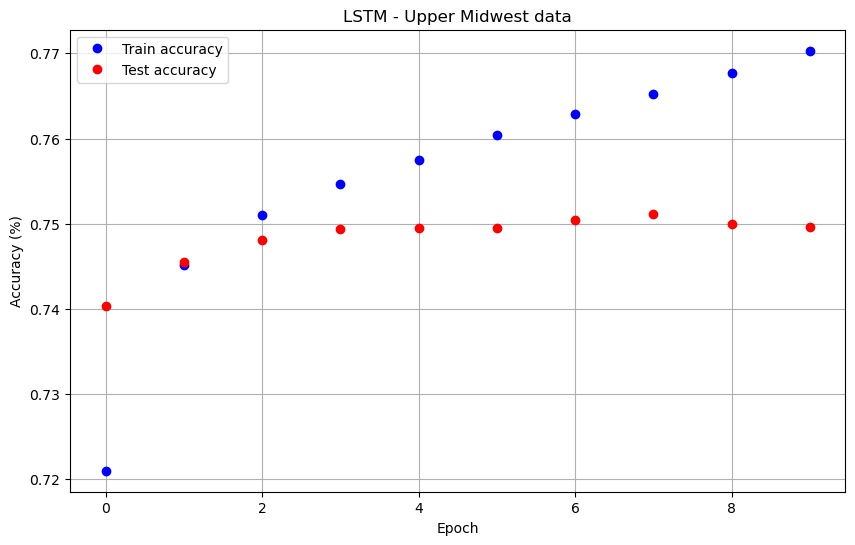

In [84]:
# Train test loops
train_accs = []
test_accs = []

epochs = 10
for epoch in range(epochs):
    # Training cycle
    model.train() # Set model to training mode
    
    train_running_loss = 0.0
    train_acc = 0
    
    for X_batch, y_batch in dataloader_train:
        
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        optimizer.zero_grad()
        preds = model(X_batch)
        
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        train_running_loss += loss.item()
        train_acc += accuracy_fn(preds, y_batch)

    train_acc = train_acc / (batch_size*len(dataloader_train))
    train_accs.append(train_acc)
    train_loss = train_running_loss / len(dataloader_train)

    # Testing loop
    model.eval() # Set model to evaluation mode
    test_running_loss = 0.0
    test_acc = 0

    with torch.no_grad():  # Disable gradient calculations during testing
        for X_batch_test, y_batch_test in dataloader_test:
            
            X_batch_test = X_batch_test.to(device)
            y_batch_test = y_batch_test.to(device)

            test_preds = model(X_batch_test)
            test_loss = criterion(test_preds, y_batch_test)

            test_running_loss += loss.item()
            test_acc += accuracy_fn(test_preds, y_batch_test)

    test_acc = test_acc / (batch_size*len(dataloader_test))
    test_accs.append(test_acc)
    test_loss = test_running_loss / len(dataloader_test)

    print(f'Epoch {epoch + 1}: Train loss {train_loss:.3f}, acc {train_acc:.3f} | Test loss {test_loss:.3f}, acc {test_acc:.3f}')
    
plot_lists_with_colors(train_accs, test_accs, label1="Train accuracy", label2="Test accuracy")

In [97]:
## Save the model here
torch.save(model, 'model-mid-enc.pth')